## **Assignment Simple machine Learning Project cycle**

### **_House Price Prediction Using California Housing Data_**
This dataset provides information about house prices in California. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "California Housing Dataset" from sklearn.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (California Housing):
* MedInc: Median income in block group
* HouseAge: Median house age in block group
* AveRooms: Average number of rooms per household
* AveBedrms: Average number of bedrooms per household
* Population: Block group population
* AveOccup: Average number of household members
* Latitude: Block group latitude
* Longitude: Block group longitude
* MedHouseVal (Target): Median house value in block group




In [2]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Example: import pandas as pd
# Add your imports here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



In [3]:
# --- Data Collection and Loading ---
# TODO: Load the 'California Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `fetch_california_housing()` from `sklearn.datasets`

# Load dataset and convert to DataFrame:

housing_Data = fetch_california_housing()

# Convert into DataFrame

df = pd.DataFrame(housing_Data.data, columns=housing_Data.feature_names)

# Add target variable

df["MedHouseVal"] = housing_Data.target



In [4]:
# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.
print (df.head().to_string())

print ("\n","After adding target column : ")
print(df.head().to_string())



   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88    -122.23        4.526
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86    -122.22        3.585
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85    -122.24        3.521
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85    -122.25        3.413
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85    -122.25        3.422

 After adding target column : 
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88    -122.23        4.526
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86    -122.22        3.585
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85    -122.24        3.52

In [5]:

# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.

print("To inspect data types")
print( df.info())

print("\n","statistical properties")
print(df.describe().round(2).to_string())


To inspect data types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

 statistical properties
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00  20640.00   20640.00     20640.00
mean       3.87     28.64      5.43       1.10     1425.48      3.07     35.63    -119.57         2.07
std        1.90     12.59    

In [6]:

# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.

print("To check for null values",df.isnull().sum())



To check for null values MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


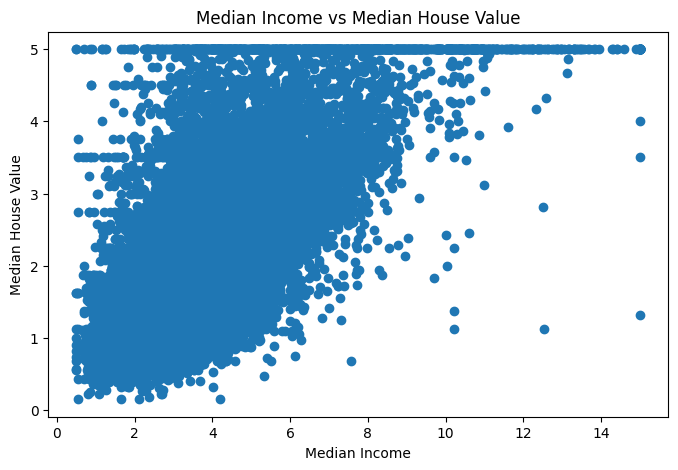

In [7]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable (MedHouseVal).
# Example: Use `plt.scatter()` to visualize the relationship between 'MedInc' and 'MedHouseVal'.

plt.figure(figsize=(8,5))

plt.scatter(df["MedInc"], df["MedHouseVal"])

plt.xlabel("Median Income")

plt.ylabel("Median House Value")

plt.title("Median Income vs Median House Value")

plt.show()




**Observation:** The scatter plot shows that there is a positive relationship between Median Income and Median House Value. This means that areas with higher median income generally have higher house prices. However, the points are not in a straight line because other factors, such as house age, number of rooms, and location, also affect house prices. The horizontal line at the top appears because the maximum house value in this dataset is limited to 5.0.

In [8]:
# TODO: Create a function to automate scatter plots for all features vs MedHouseVal.
# Hint: The function should loop over a list of features and plot scatter plots for each.

# Function to create scatter plots for all features

def scatter_plots(features):

    for feature in features:

        plt.figure(figsize=(8,4))

        plt.scatter(df[feature], df["MedHouseVal"], alpha=0.5)

        plt.xlabel(feature)
        plt.ylabel("MedHouseVal")
        plt.title(f"{feature} vs MedHouseVal")

        plt.show()


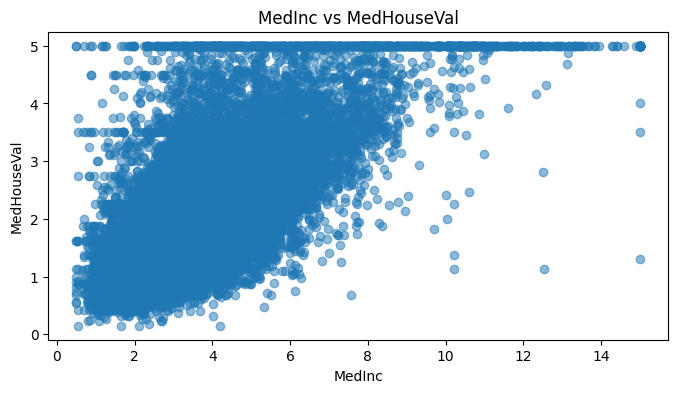

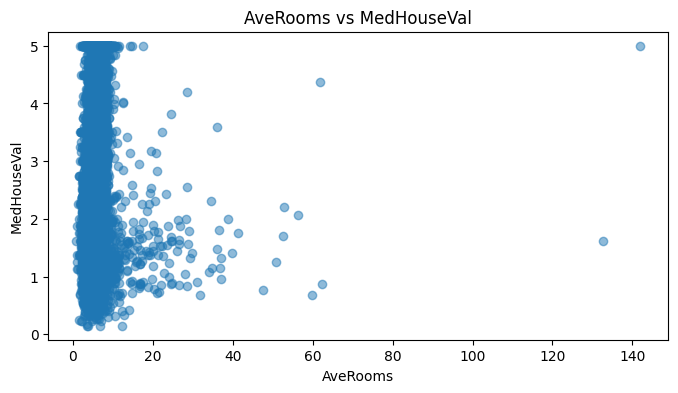

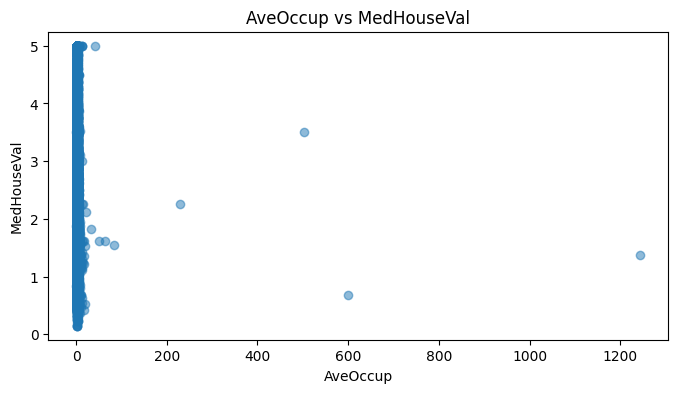

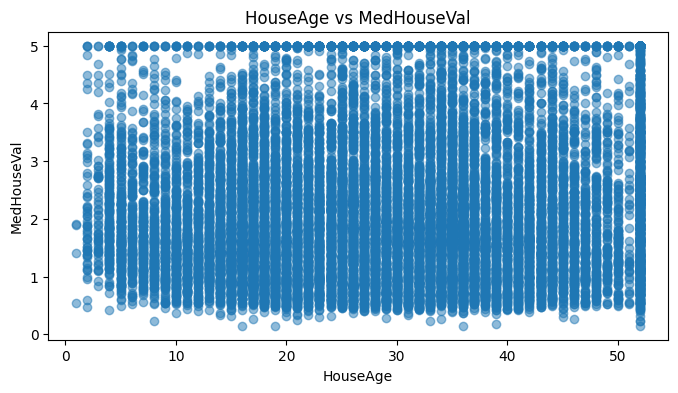

In [9]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Features: ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
# Target: 'MedHouseVal'

# List of selected features
features = ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']

# Use the function to create scatter plots
scatter_plots(features)

**Observation**
**MedInc vs MedHouseVal:** There is a positive relationship between median income and house value. Areas with higher income generally have higher house prices.
**AveRooms vs MedHouseVal:** Houses with more average rooms tend to have slightly higher house values, but the relationship is not very strong.
**AveOccup vs MedHouseVal:** There is no clear relationship between average occupancy and house value. The points are scattered, showing that occupancy alone does not affect house prices much.
**HouseAge vs MedHouseVal:** House age has a weak relationship with house value. Both newer and older houses can have high or low prices.
**Overall Observation:** Among these features, Median Income (MedInc) has the strongest relationship with Median House Value. The other features also influence house prices, but their relationship with the target is weaker.

In [10]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.

# Features or Independent variables
X = df.drop("MedHouseVal", axis=1)

# Target or Dependent variable
y = df["MedHouseVal"]

# Split the dataset into 80% training and 20% testing

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Check the shapes
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (16512, 8)
Testing Features: (4128, 8)
Training Target: (16512,)
Testing Target: (4128,)


**Observation :** The dataset was successfully split into 80% training data and 20% testing data. The training set contains 16,512 houses with 8 input features, while the testing set contains 4,128 houses with the same 8 features. The training target and testing target contain the corresponding house prices for each house. The training data is used to teach the model, and the testing data is used to check how accurately the model predicts house prices on unseen data.

In [11]:
# TODO: Choose an appropriate regression model.
# Hint: Use `LinearRegression()` from `sklearn.linear_model`.

model = LinearRegression()


In [12]:
# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.
# Train the model

model.fit(X_train, y_train)



LinearRegression()

In [13]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

# Predict on the test set and calculate the evaluation metrics:

y_pred = model.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Display results
print("RMSE:", rmse)
print("R-squared:", r2)



RMSE: 0.7455813830127764
R-squared: 0.5757877060324508


**Observation:** The Linear Regression model achieved an RMSE of 0.7456 and an R² score of 0.5758. The RMSE shows that the predicted house values are, on average, about 0.75 units away from the actual values. The R² score indicates that the model explains about 57.6% of the variation in house prices. This shows that the model has moderate prediction performance and can predict house prices reasonably well, although there is still room for improvement.

In [16]:

# --- Model Prediction ---
# TODO: Predict Median House Value from a new set of feature inputs.
# Example new data: 'MedInc' = 3, 'HouseAge' = 30, 'AveRooms' = 6, 'AveOccup' = 3, 'Latitude' = 34, 'Longitude' = -118, 'AveBedrms' = 1, 'Population' = 1500
# Hint: Use `.predict()` on a new data array.

# New house data (as a list of values matching the feature order)
new_house_data = [[5.5, 20, 7, 1, 1200, 3, 37.5, -122.0]]

# Get feature names from the original DataFrame's columns, excluding the target
feature_names = X.columns.tolist()

# Convert new_house_data to a DataFrame with feature names
new_house_df = pd.DataFrame(new_house_data, columns=feature_names)

# Predict the median house value
predicted_value = model.predict(new_house_df)

# Display the prediction
print("Predicted Median House Value:", predicted_value[0])


Predicted Median House Value: 2.7159521328380833


**Observation:**: The trained Linear Regression model predicted a Median House Value of approximately 2.72 for the new house. Since the target variable is measured in hundreds of thousands of dollars, this corresponds to an estimated house price of about $272,000. This prediction is based on the input features provided to the model.

git repo Link : https://github.com/7500nidhi/Artificial_Intelligence_Course.git